In [1]:
# Pydatasets

In [3]:
from pydataset import data

In [4]:
data()

,dataset_id,title
0,AirPassengers,Monthly Airline Passenger Numbers 1949-1960
1,BJsales,Sales Data with Leading Indicator
2,BOD,Biochemical Oxygen Demand
3,Formaldehyde,Determination of Formaldehyde
4,HairEyeColor,Hair and Eye Color of Statistics Students
...,...,...
752,VerbAgg,Verbal Aggression item responses
753,cake,Breakage Angle of Chocolate Cakes
754,cbpp,Contagious bovine pleuropneumonia
755,grouseticks,Data on red grouse ticks from Elston et al. 2001


In [6]:
iris = data('iris')

In [7]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa


In [9]:
mtcars = data('mtcars')
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [10]:
titanic = data('Titanic')
titanic.head()

,Class,Sex,Age,Survived,Freq
1,1st,Male,Child,No,0
2,2nd,Male,Child,No,0
3,3rd,Male,Child,No,35
4,Crew,Male,Child,No,0
5,1st,Female,Child,No,0


In [19]:
from pydataset import data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import export_text

df = data('iris')



In [13]:
X = df.drop('Species', axis=1)
y = df['Species']
print(X[0:10], y[0:10])

    Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
1            5.1          3.5           1.4          0.2
2            4.9          3.0           1.4          0.2
3            4.7          3.2           1.3          0.2
4            4.6          3.1           1.5          0.2
5            5.0          3.6           1.4          0.2
6            5.4          3.9           1.7          0.4
7            4.6          3.4           1.4          0.3
8            5.0          3.4           1.5          0.2
9            4.4          2.9           1.4          0.2
10           4.9          3.1           1.5          0.1 1     setosa
2     setosa
3     setosa
4     setosa
5     setosa
6     setosa
7     setosa
8     setosa
9     setosa
10    setosa
Name: Species, dtype: object


In [14]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)
print(X_train[0:5], X_test[0:5], y_train[0:5], y_test[0:5])

     Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
82            5.5          2.4           3.7          1.0
134           6.3          2.8           5.1          1.5
138           6.4          3.1           5.5          1.8
76            6.6          3.0           4.4          1.4
110           7.2          3.6           6.1          2.5      Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
74            6.1          2.8           4.7          1.2
19            5.7          3.8           1.7          0.3
119           7.7          2.6           6.9          2.3
79            6.0          2.9           4.5          1.5
77            6.8          2.8           4.8          1.4 82     versicolor
134     virginica
138     virginica
76     versicolor
110     virginica
Name: Species, dtype: object 74     versicolor
19         setosa
119     virginica
79     versicolor
77     versicolor
Name: Species, dtype: object


In [22]:
X_train.shape

(105, 4)

In [ ]:
rf = RandomForestClassifier( n_estimators=200,   max_depth=None,  random_state=42)

In [15]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [16]:
y_pred = rf.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [20]:
# Pick one tree (e.g., first tree)
tree = rf.estimators_[0]

tree_rules = export_text(tree, feature_names=list(X.columns))
print(tree_rules)

|--- Petal.Width <= 1.65
|   |--- Petal.Width <= 0.80
|   |   |--- class: 0.0
|   |--- Petal.Width >  0.80
|   |   |--- Petal.Length <= 4.85
|   |   |   |--- class: 1.0
|   |   |--- Petal.Length >  4.85
|   |   |   |--- Petal.Width <= 1.55
|   |   |   |   |--- class: 2.0
|   |   |   |--- Petal.Width >  1.55
|   |   |   |   |--- class: 1.0
|--- Petal.Width >  1.65
|   |--- Petal.Length <= 4.85
|   |   |--- Petal.Length <= 4.65
|   |   |   |--- class: 2.0
|   |   |--- Petal.Length >  4.65
|   |   |   |--- Sepal.Length <= 6.05
|   |   |   |   |--- class: 1.0
|   |   |   |--- Sepal.Length >  6.05
|   |   |   |   |--- class: 2.0
|   |--- Petal.Length >  4.85
|   |   |--- class: 2.0



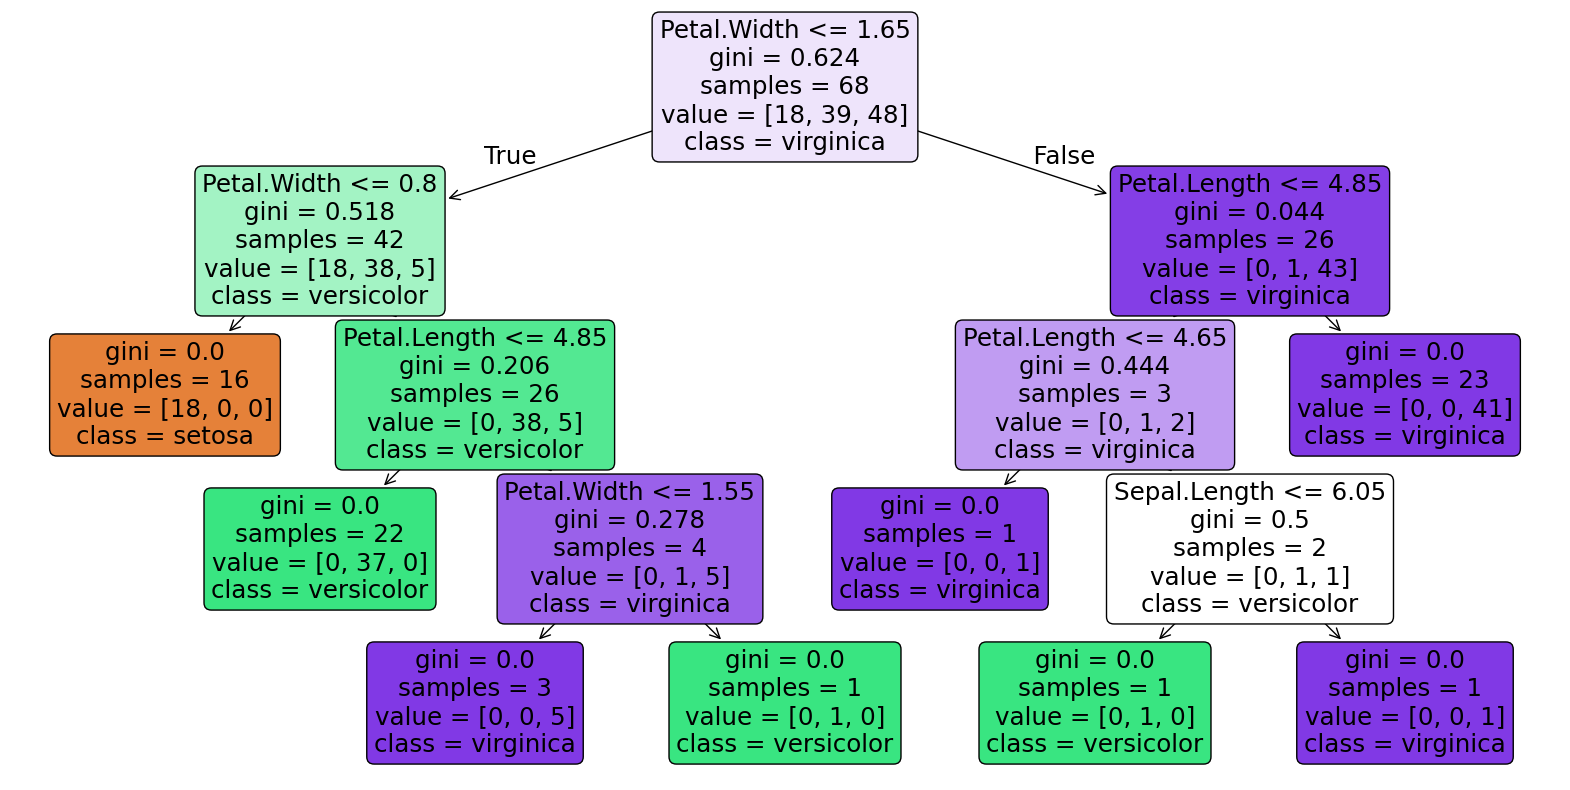

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(    rf.estimators_[0],    feature_names=X.columns,    class_names=rf.classes_,
    filled=True,
    rounded=True
)
plt.show()

In [23]:
import pandas as pd

pd.Series(     rf.feature_importances_,  index=X.columns ).sort_values(ascending=False)

Petal.Length    0.432983
Petal.Width     0.416397
Sepal.Length    0.106245
Sepal.Width     0.044375
dtype: float64